---
 Title: Week 10 - Binomial Distributions & Random Data    
 Author: Tres Reeves  
 Date: 16 August 2026  
 Description: This week, we are working with Binomial Distributions, an ensemble model that uses majority voting to predict a binary target, and random data.      

---
---
 Title: Python - Binomial Distribution                 
 Author: Geeksforgeeks                   
 Date: 16 July 2020           
 Description: Quick reference on Binomial distributions in Python.       
 URL: https://www.geeksforgeeks.org/python/python-binomial-distribution/                                       

---
---
 Title: Binomial Distribution and Binomial Distribution in Python                  
 Author: Maji Souvik                 
 Date: 15 April 2025              
 Description: Binomial distributions in Python              
 URL: https://medium.com/@maji1996souvik/binomial-distribution-and-binomial-distribution-in-python-3651a4fc7c33             

---
---
 Title: Mastering Random Variables: A Data Scientist’s Guide to PMF, PDF, and Expectation                
 Author: Emama Shahzad                      
 Date: 23 Feburary 2025              
 Description: Reference on getting the theoretical mean and Standard deviation                                
 URL: https://medium.com/@emama._.shahzad/mastering-random-variables-a-data-scientists-guide-to-pmf-pdf-and-expectation-724c49a79595              

---

# Using the Binomial Distribution

An ensemble model is a model that uses multiple diﬀerent models to build a better model. E.g., a
random forest classifier uses multiple decision trees to “vote” for the best answer. For this exercise,
assume that an ensemble model uses majority vote to predict a binary target and that each individual
model is independent of every other model. Use Python code to answer the following questions.

**Hint:** The binom package from scipy.stats is useful for this problem, but make sure you are using
the correct functions for your calculations.

In [56]:
# Importing libary 
from scipy.stats import binom

(a) If an ensemble model is composed of 15 individual models that each have 63% accuracy, what is
the ensemble model accuracy?

In [57]:
# Number of models 
n = 15 

# Individual model accuracy 
p = 0.63 

# Model would need 8 out of 15 for the majorit
m = 8 

# Calculating the ensemble accuracy 
ensemle_accuracy = 1 - binom.cdf(7, n, p)

# Results
print(f"Ensemble accuracy: {ensemle_accuracy:.4f}")


Ensemble accuracy: 0.8513


(b) What would the accuracy of the 15 individual models need to be in order for the ensemble model
to have 95% accuracy? Find the smallest whole number percentage so this is satisfied.

In [58]:
# Number of models 
n = 15 

# Model would need 8 out of 15 for the majorit
m = 8 

# Target accuracy 
t = 0.95 

# Checking the individual accuracy percentages from 50% to 100% 
for prob_percent in range(50, 101):
    p = prob_percent / 100
    
    # Calculating the ensemble accuracy
    ensemble_acc = 1 - binom.cdf(7, n, p)

    # Prints the results for the percentage that hits 95% or higher first
    if ensemble_acc >= t:
        print(f"Smallest p: {prob_percent}%\n Ensemble accuracy = {ensemble_acc:.4f}")
        break 



Smallest p: 71%
 Ensemble accuracy = 0.9587


(c) If each individual model has 63% accuracy, how many individual models are needed for the
ensemble model to have 95% accuracy? Find the smallest odd number of models (so there is a
clear majority), so that this is satisfied.

In [59]:
# Individual model accuracy 
p = 0.63

# Target accuracy 
t = 0.95

# Starting with smalled odd number 
n = 1 

while True: 
    # only testing for odd n 
    if n % 2 == 1: 

        # Majority needed out of n models 
        majority = n // 2 + 1

        # Calculating the ensemble accuracy
        ensemble_acc = 1 - binom.cdf(majority - 1, n, p)

        # Loops until we hit the target, which is the smallest n 
        if ensemble_acc >= t:
            print(f"Smallest odd n: {n}\n Ensemble accuracy = {ensemble_acc:.4f}")
            break

    # Increasing n in every pass within the loop, or n never changes and runs forever
    n += 1

Smallest odd n: 39
 Ensemble accuracy = 0.9518


# Working with Random Data

Suppose that a random variable X can take on values 1, 2, 3, 4, or 5.

**Note:** You can combine as much as you like of parts (b) and (c) into a single function. They are
separate in the problem statement to make sure what you need to do is clear.

In [60]:
# Importing Libarary 
import numpy as np 
import matplotlib.pyplot as plt 

(a) Make up your own probability mass function (pmf) for X. Make sure it satisfies the requirements
of a pmf.

In [61]:
# Random variables and probabilities 
x_values = [1, 2, 3, 4, 5]
prob_values = [0.10, 0.15, 0.20, 0.25, 0.30]

# Printing sum - should equal 1
print(sum(prob_values))

1.0


(b) Build a function that will generate 50 random X-values from the pmf you created in part (a) and
return the mean of these values.

In [62]:
# Function 
def sample_mean(x_values, prob_values, n=50):
    # Generating random sample matching our probability distribution 
    samples = np.random.choice(x_values,  p=prob_values, size=n,)

    # Calculating and returning the average of the samples
    return samples.mean() 

# Example of the random x_values 
current_sample_mean = sample_mean(x_values, prob_values, 50)
print(f"The mean of 50 random X-values is: {current_sample_mean}")

The mean of 50 random X-values is: 3.6


(c) Now, build a function that will run your function in part (b), 1, 000 times and store the means in
a list.

In [63]:
# Function 
def generate_means(values, probs, n_runs=1000, size=50):

    # Random sample and runs 1000 times 
    means = [sample_mean(values, probs, size) for _ in range(n_runs)]
    return means

(d) Create a histogram of the means in the list from part (c). Describe the shape of this histogram.
What theorem tells us that it will look the way it does?

**Answer:**       
The histogram of the 1000 sample means is a bell-shaped and symmetric distribution centered around 3.4-3.5. What is notable about this histogram is that the underlying pmf, which I defined in part (a), is not symmetric. Despite the skew, averaging 50 draws at a time and repeating the process 1000 times produces a mean that resembles a normal distribution. The Central Limit Theorem states that the sampling distribution of the mean approaches a normal distribution as the sample size increases, regardless of the original shape of the population.       

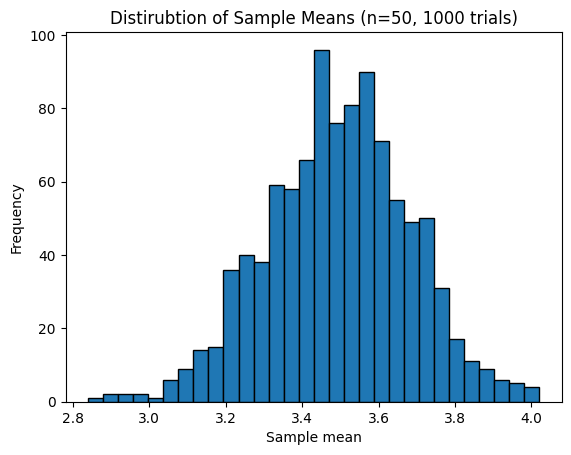

In [64]:
# Running the sample process 1000 times 
means = generate_means(x_values, prob_values)

# Histogram plot of the 1000 sample means 
plt.hist(means, bins=30, edgecolor='black')

# Labels 
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Distirubtion of Sample Means (n=50, 1000 trials)')
plt.show()

(e) What is the mean and standard deviation of your list of means? What are their theoretical values?

**Answer:**             
Both the empirical mean and the theoretical population mean are close together. The theoretical mean is 3.50, while the empirical mean is 3.5054. The standard deviation of the empirical is 0.1905, while the theoretical is 0.1871. This confirms that the sample mean is an unbiased estimator of the population mean.

In [65]:
x_values = np.array(x_values)
prob_values = np.array(prob_values)

# Theoretical mean: sum of (value * probability)
mu_t = np.sum(x_values * prob_values)

# Theoretical variance: sum of probability * (value - mean)^2
var_t = np.sum(prob_values * (x_values - mu_t)**2)
sigma_t = np.sqrt(var_t)

# Standard error of the sample mean (n=50)
se_t = sigma_t / np.sqrt(50)

# Empirical values from your 1,000 sample means
mean_of_means = np.mean(means)
std_of_means = np.std(means)

print(f"Theoretical mean: {mu_t}")
print(f"Theoretical SE: {se_t:.4f}")
print(f"Empirical mean of means: {mean_of_means:.4f}")
print(f"Empirical std of means: {std_of_means:.4f}")

Theoretical mean: 3.5
Theoretical SE: 0.1871
Empirical mean of means: 3.4959
Empirical std of means: 0.1906
